# Does `BC555_sample_05/disk` actually have a fixed hot pixel?

Follow-up on `2026_09_02_2245_merlin_hot_pixel_fiducial_warp_risk.md` /
`2026_09_02_2300_bc555_disk_median_filter_fiducial_ab_run.md`: that session
established the *mechanistic* risk (MERlin's current default recipe has
`median_filter` off) and ran an A/B `median_filter` comparison on
`BC555_sample_05/disk` that came back a **null result** -- but never actually
looked at the raw pixel data to check whether this dataset even *has* a hot
pixel in the first place. This notebook answers that directly.

**Method**: `remove_hot_pixels` (`MERci.acquisition.alignment`, already used
by this repo's other bead-analysis notebooks) flags a pixel as "hot" when it
exceeds `ratio`x its own local (3x3) median AND clears a MAD-based noise
floor. A real bead spans several pixels and sits on a bright neighbourhood
(its own local median is high too); a genuine fixed hot/defective sensor
pixel does not move between physical fields of view, so if the *same*
`(row, col)` gets flagged across many independent, randomly-chosen FOVs --
each imaging a different, unrelated patch of tissue -- that recurrence can
only be explained by a camera artifact, not sample content.

Raw beads frame (frame index 0) of the `cells` round, `disk` only (that's
the dataset in question here -- `epi`'s own weak-averaging-gain result was
already normal, see `test_bead_background_correction.ipynb`'s
characterization: `epi`'s beads frame has real bead signal, not a
near-dark-level background).

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# notebooks/tests/<subfolder>/ is three levels under the repo root (MERci/),
# same convention as notebooks/before_imaging/regular/ (3 levels).
MERCI_DIR = Path(os.getcwd()).parent.parent.parent   # MERci/

sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.common.config          import ExperimentConfig
from MERci.common.metadata        import ExperimentMetadata
from MERci.common.io              import read_image_frames
from MERci.common.experiment_info import load_experiment_info, resolve_sample_identity, positions_file_tag
from MERci.acquisition.alignment  import remove_hot_pixels
from MERci.progress_display       import ProgressReporter
from MERci.visualization import get_merci_figures_dir

NOTEBOOK_NAME = "test_hot_pixel_detection"
print(f"MERCI_DIR : {MERCI_DIR}")

MERCI_DIR : /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci


## 2 — Parameters

In [2]:
SAMPLE_DIR = Path("/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk")
IMAGE_SUFFIX = ".zarr"
BEAD_FRAME_INDEX = 0          # raw camera frame 0 = fiducial/focus-lock frame, every round's stack

N_FOVS = 80                   # independent FOVs sampled (different tissue patches each)
SEED = 0
LOCAL_WINDOW = 3               # remove_hot_pixels' own local-median window (its default)
RECUR_THRESHOLD = 2            # a pixel flagged in >= this many independent FOVs is a real candidate,
                                # not a one-off real bead core that happened to spike once

FORCE_RECOMPUTE = False

PLOT_TITLE_FONTSIZE  = 14
PLOT_LABEL_FONTSIZE  = 12
PLOT_TICK_FONTSIZE   = 11
PLOT_LEGEND_FONTSIZE = 10

print(f"SAMPLE_DIR: {SAMPLE_DIR}")

SAMPLE_DIR: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk


## 3 — Resolve dataset geometry + pick `N_FOVS` random FOVs

Random (not spatially clustered) so any recurring flagged pixel can only be
a camera artifact, never a real repeated tissue feature -- the FOVs below
each image a different, non-overlapping-by-more-than-a-few-percent patch of
the tissue.

In [3]:
sample_name, imaging_dir = resolve_sample_identity(SAMPLE_DIR / "MERci")
positions_tag = positions_file_tag(sample_name, imaging_dir)
info = load_experiment_info(SAMPLE_DIR / "metadata" / "experiment_info.yaml")
microscope = info.microscope

config = ExperimentConfig(
    data_dir       = SAMPLE_DIR / "data",
    metadata_dir   = SAMPLE_DIR / "metadata",
    analysis_dir   = SAMPLE_DIR / "analysis",
    settings_dir   = SAMPLE_DIR / "settings",
    round_info_csv = SAMPLE_DIR / "metadata" / "round_info.csv",
    positions_txt  = SAMPLE_DIR / "positions" / f"positions_{positions_tag}.txt",
    image_suffix   = IMAGE_SUFFIX,
    microscope     = microscope,
)
meta = ExperimentMetadata.load(config.round_info_csv, config.positions_txt, config.data_dir,
                                image_suffix=config.image_suffix)

cells_round_id = next(rid for rid in meta.valid_round_ids()
                       if meta.series_for_round(rid)[0].imaging_type.strip().lower() == "cells")
series = meta.series_for_round(cells_round_id)[0]

rng = np.random.default_rng(SEED)
all_fovs = sorted(meta.fovs)
sample_fovs = sorted(int(f) for f in rng.choice(all_fovs, size=N_FOVS, replace=False))

figures_dir = get_merci_figures_dir(SAMPLE_DIR, "tests", NOTEBOOK_NAME, subfolder="fov_stitching")
figures_dir.mkdir(parents=True, exist_ok=True)
cache_dir = config.analysis_dir / "cache" / NOTEBOOK_NAME
cache_dir.mkdir(parents=True, exist_ok=True)

print(f"microscope        : {microscope}")
print(f"cells round        : {cells_round_id}")
print(f"total FOVs         : {len(all_fovs)}")
print(f"sampled FOVs (seed={SEED}): {len(sample_fovs)}")

microscope        : ST2
cells round        : 1
total FOVs         : 603
sampled FOVs (seed=0): 80


## 4 — Load each sampled FOV's raw beads frame, run `remove_hot_pixels`

For every frame: the boolean "flagged as hot" mask (raw != corrected), plus
the raw value and 7x7 local-median background at every pixel the mask ever
fires on. Cached -- `N_FOVS` full-frame reads is the slow part
(~1.2s/frame).

In [4]:
occ_path = cache_dir / "occurrence_map.npy"
trace_path = cache_dir / "flagged_pixel_traces.csv"

if occ_path.exists() and trace_path.exists() and not FORCE_RECOMPUTE:
    occurrence_map = np.load(occ_path)
    trace_df = pd.read_csv(trace_path)
    print(f"Loaded cached result: {occ_path}, {trace_path}")
else:
    occurrence_map = None
    trace_rows = []
    reporter = ProgressReporter(total=len(sample_fovs), label="Scanning FOVs for hot pixels")
    for fov_id in reporter.wrap(sample_fovs):
        path = series.resolve_path(fov_id, config.image_suffix)
        frame = read_image_frames(path, [BEAD_FRAME_INDEX],
                                   frame_width=config.frame_width, frame_height=config.frame_height)[0]
        corrected = remove_hot_pixels(frame, size=LOCAL_WINDOW)
        flagged = corrected != frame

        if occurrence_map is None:
            occurrence_map = np.zeros(frame.shape, dtype=np.int32)
        occurrence_map += flagged.astype(np.int32)

        for y, x in zip(*np.where(flagged)):
            trace_rows.append({"fov": fov_id, "y": int(y), "x": int(x),
                                "raw_value": int(frame[y, x]),
                                "local_median": float(corrected[y, x])})

    trace_df = pd.DataFrame(trace_rows)
    np.save(occ_path, occurrence_map)
    trace_df.to_csv(trace_path, index=False)
    print(f"Saved: {occ_path}, {trace_path}")

print(f"Frame shape: {occurrence_map.shape}")
print(f"Unique pixel locations flagged at least once: {(occurrence_map > 0).sum()}")
print(f"Max occurrence (out of {len(sample_fovs)} FOVs): {occurrence_map.max()}")

Scanning FOVs for hot pixels: [------------------------] 1/80 (  1.2%)  elapsed 1s  ETA 1m 49s          

Scanning FOVs for hot pixels: [------------------------] 2/80 (  2.5%)  elapsed 3s  ETA 1m 38s          

Scanning FOVs for hot pixels: [------------------------] 3/80 (  3.8%)  elapsed 4s  ETA 1m 46s          

Scanning FOVs for hot pixels: [#-----------------------] 4/80 (  5.0%)  elapsed 6s  ETA 1m 46s          

Scanning FOVs for hot pixels: [#-----------------------] 5/80 (  6.2%)  elapsed 7s  ETA 1m 40s          

...

Scanning FOVs for hot pixels: [#######################-] 78/80 ( 97.5%)  elapsed 1m 45s  ETA 3s          

Scanning FOVs for hot pixels: [#######################-] 79/80 ( 98.8%)  elapsed 1m 46s  ETA 1s          

Scanning FOVs for hot pixels: [########################] 80/80 (100.0%)  elapsed 1m 47s  ETA 0s          

Scanning FOVs for hot pixels: [########################] 80/80 (100.0%)  elapsed 1m 47s  ETA 0s          


Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/cache/test_hot_pixel_detection/occurrence_map.npy, /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/cache/test_hot_pixel_detection/flagged_pixel_traces.csv
Frame shape: (2304, 2304)
Unique pixel locations flagged at least once: 14
Max occurrence (out of 80 FOVs): 34


## 5 — Recurring candidates

A pixel flagged by `remove_hot_pixels` in only 1 of `N_FOVS` frames is
consistent with an ordinary real bead core that happened to spike above the
ratio threshold once -- not evidence of a fixed defect. A pixel flagged in
`>= RECUR_THRESHOLD` independent, randomly-located FOVs cannot be explained
by sample content.

In [5]:
ys, xs = np.where(occurrence_map >= RECUR_THRESHOLD)
order = np.argsort(-occurrence_map[ys, xs])
candidates = [(int(ys[i]), int(xs[i]), int(occurrence_map[ys[i], xs[i]])) for i in order]

candidates_df = pd.DataFrame(candidates, columns=["y", "x", "n_fovs_flagged"])
candidates_df["frac_fovs_flagged"] = candidates_df["n_fovs_flagged"] / len(sample_fovs)
print(f"Candidates recurring in >= {RECUR_THRESHOLD}/{len(sample_fovs)} independent FOVs:")
print(candidates_df.to_string(index=False))

Candidates recurring in >= 2/80 independent FOVs:
   y    x  n_fovs_flagged  frac_fovs_flagged
1214 1008              34              0.425
 849  364               2              0.025


## 6 — Full intensity trace for each candidate, across ALL sampled FOVs

Not just the frames where it happened to clear the flagging threshold --
every sampled FOV, to see whether the pixel's raw value stays essentially
constant (a fixed defect) regardless of which patch of tissue that FOV
imaged, and how it compares to the local background and to the rest of that
same frame.

In [6]:
def candidate_full_trace(y, x, half_win=10):
    rows = []
    reporter = ProgressReporter(total=len(sample_fovs), label=f"Full trace @ ({y},{x})")
    for fov_id in reporter.wrap(sample_fovs):
        path = series.resolve_path(fov_id, config.image_suffix)
        frame = read_image_frames(path, [BEAD_FRAME_INDEX],
                                   frame_width=config.frame_width, frame_height=config.frame_height)[0]
        local_win = frame[y - half_win:y + half_win + 1, x - half_win:x + half_win + 1].astype(float)
        local_med = float(np.median(local_win))
        rows.append({"fov": fov_id, "value": int(frame[y, x]), "local_median": local_med,
                      "frame_global_max": int(frame.max()),
                      "is_frame_argmax": bool(np.unravel_index(np.argmax(frame), frame.shape) == (y, x))})
    return pd.DataFrame(rows)


full_traces_path = cache_dir / "candidate_full_traces.csv"
if full_traces_path.exists() and not FORCE_RECOMPUTE:
    full_traces = pd.read_csv(full_traces_path)
else:
    parts = []
    for _, row in candidates_df.iterrows():
        t = candidate_full_trace(int(row["y"]), int(row["x"]))
        t["y"], t["x"] = int(row["y"]), int(row["x"])
        parts.append(t)
    full_traces = pd.concat(parts, ignore_index=True)
    full_traces.to_csv(full_traces_path, index=False)
    print(f"Saved: {full_traces_path}")

for (y, x), g in full_traces.groupby(["y", "x"]):
    ratio = g["value"] / g["local_median"].clip(lower=1)
    print(f"\nCandidate ({y},{x}):")
    print(f"  raw value        : min={g['value'].min()}  max={g['value'].max()}  "
          f"mean={g['value'].mean():.1f}  std={g['value'].std():.1f}")
    print(f"  local median (21x21): mean={g['local_median'].mean():.1f}")
    print(f"  value / local_median ratio: mean={ratio.mean():.2f}  min={ratio.min():.2f}")
    print(f"  is single brightest pixel in frame: {g['is_frame_argmax'].sum()}/{len(g)} sampled FOVs")

Full trace @ (1214,1008): [------------------------] 1/80 (  1.2%)  elapsed 0s  ETA 2s          

Full trace @ (1214,1008): [#######-----------------] 25/80 ( 31.2%)  elapsed 1s  ETA 1s          

Full trace @ (1214,1008): [##############----------] 49/80 ( 61.2%)  elapsed 1s  ETA 1s          

Full trace @ (1214,1008): [#####################---] 72/80 ( 90.0%)  elapsed 2s  ETA 0s          

Full trace @ (1214,1008): [########################] 80/80 (100.0%)  elapsed 2s  ETA 0s          

...

Full trace @ (849,364): [################--------] 56/80 ( 70.0%)  elapsed 2s  ETA 1s          

Full trace @ (849,364): [######################--] 76/80 ( 95.0%)  elapsed 2s  ETA 0s          

Full trace @ (849,364): [########################] 80/80 (100.0%)  elapsed 2s  ETA 0s          

Full trace @ (849,364): [########################] 80/80 (100.0%)  elapsed 2s  ETA 0s          


Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/cache/test_hot_pixel_detection/candidate_full_traces.csv

Candidate (849,364):
  raw value        : min=423  max=554  mean=491.6  std=24.6
  local median (21x21): mean=105.4
  value / local_median ratio: mean=4.66  min=4.03
  is single brightest pixel in frame: 2/80 sampled FOVs

Candidate (1214,1008):
  raw value        : min=504  max=685  mean=579.5  std=43.5
  local median (21x21): mean=114.1
  value / local_median ratio: mean=5.08  min=4.46
  is single brightest pixel in frame: 75/80 sampled FOVs


## 7 — Diagnostic figures (saved to `figures/MERci/tests/fov_stitching/`)

(a) Occurrence map -- where on the sensor pixels got flagged, and how often.
(b) Zoomed raw crops around each candidate from several different FOVs side
by side -- the same bright dot recurring regardless of tissue content is the
direct visual confirmation.
(c) Intensity trace -- candidate pixel value vs. its own local background,
across every sampled (independent) FOV.

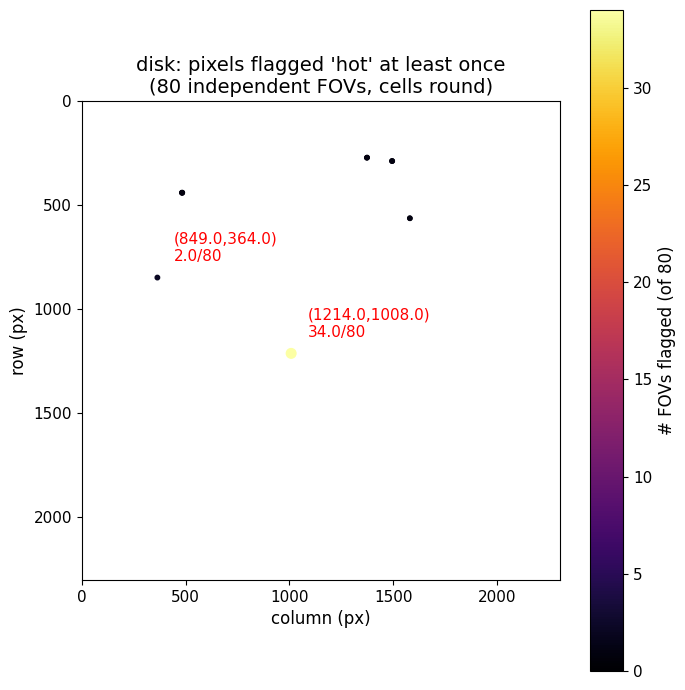

Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/figures/test_hot_pixel_detection_occurrence_map.png


In [7]:
fig, ax = plt.subplots(figsize=(7, 7))
ys_all, xs_all = np.where(occurrence_map > 0)
sizes = 8 + 40 * (occurrence_map[ys_all, xs_all] / max(occurrence_map.max(), 1))
sc = ax.scatter(xs_all, ys_all, s=sizes, c=occurrence_map[ys_all, xs_all], cmap="inferno",
                 vmin=0, vmax=occurrence_map.max())
ax.set_xlim(0, occurrence_map.shape[1])
ax.set_ylim(occurrence_map.shape[0], 0)
ax.set_aspect("equal")
ax.set_title(f"disk: pixels flagged 'hot' at least once\n({len(sample_fovs)} independent FOVs, cells round)",
             fontsize=PLOT_TITLE_FONTSIZE)
ax.set_xlabel("column (px)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("row (px)", fontsize=PLOT_LABEL_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
cb = fig.colorbar(sc, ax=ax, label=f"# FOVs flagged (of {len(sample_fovs)})")
cb.ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
cb.set_label(f"# FOVs flagged (of {len(sample_fovs)})", fontsize=PLOT_LABEL_FONTSIZE)
for _, row in candidates_df.iterrows():
    ax.annotate(f"({row.y},{row.x})\n{row.n_fovs_flagged}/{len(sample_fovs)}",
                (row.x, row.y), textcoords="offset points", xytext=(12, 12),
                fontsize=PLOT_TICK_FONTSIZE, color="red")
fig.tight_layout()
out_path = figures_dir / f"{NOTEBOOK_NAME}_occurrence_map.png"
fig.savefig(out_path, dpi=150)
plt.show()
print(f"Saved: {out_path}")

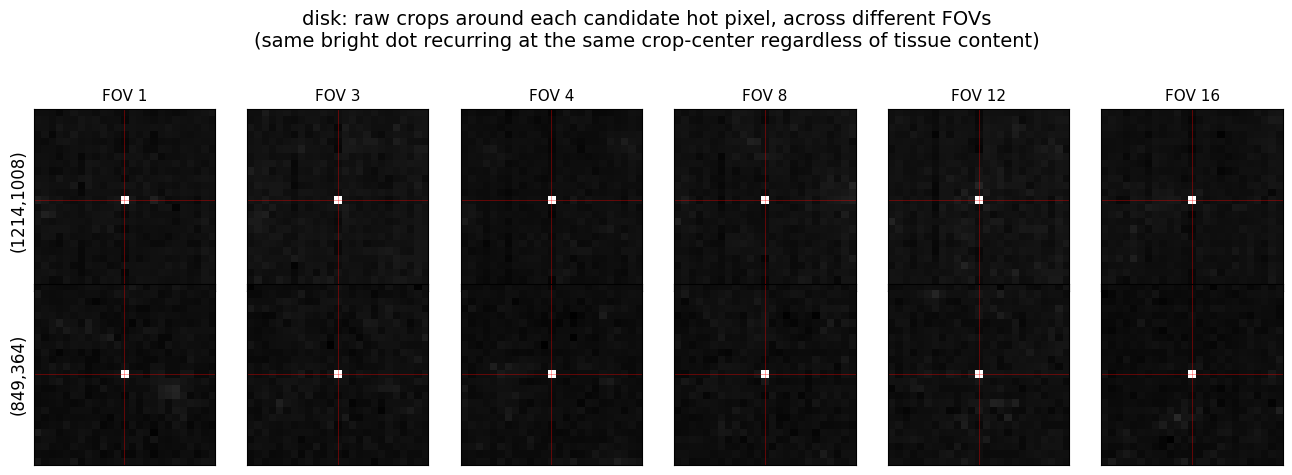

Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/figures/test_hot_pixel_detection_candidate_crops.png


In [8]:
N_EXAMPLE_FOVS = 6
HALF_WIN = 12

example_fovs = sample_fovs[:N_EXAMPLE_FOVS]
n_cand = len(candidates_df)

fig, axes = plt.subplots(n_cand, N_EXAMPLE_FOVS, figsize=(2.2 * N_EXAMPLE_FOVS, 2.4 * n_cand),
                          squeeze=False)
for row_i, (_, cand) in enumerate(candidates_df.iterrows()):
    y, x = int(cand.y), int(cand.x)
    for col_i, fov_id in enumerate(example_fovs):
        path = series.resolve_path(fov_id, config.image_suffix)
        frame = read_image_frames(path, [BEAD_FRAME_INDEX],
                                   frame_width=config.frame_width, frame_height=config.frame_height)[0]
        crop = frame[y - HALF_WIN:y + HALF_WIN + 1, x - HALF_WIN:x + HALF_WIN + 1]
        ax = axes[row_i, col_i]
        im = ax.imshow(crop, cmap="gray", vmin=frame.mean() - 20, vmax=max(frame[y, x], frame.mean() + 40))
        ax.axhline(HALF_WIN, color="red", lw=0.5, alpha=0.5)
        ax.axvline(HALF_WIN, color="red", lw=0.5, alpha=0.5)
        ax.set_xticks([]); ax.set_yticks([])
        if row_i == 0:
            ax.set_title(f"FOV {fov_id}", fontsize=PLOT_TICK_FONTSIZE)
        if col_i == 0:
            ax.set_ylabel(f"({y},{x})", fontsize=PLOT_LABEL_FONTSIZE)
fig.suptitle("disk: raw crops around each candidate hot pixel, across different FOVs\n"
             "(same bright dot recurring at the same crop-center regardless of tissue content)",
             fontsize=PLOT_TITLE_FONTSIZE)
fig.tight_layout(rect=[0, 0, 1, 0.94])
out_path = figures_dir / f"{NOTEBOOK_NAME}_candidate_crops.png"
fig.savefig(out_path, dpi=150)
plt.show()
print(f"Saved: {out_path}")

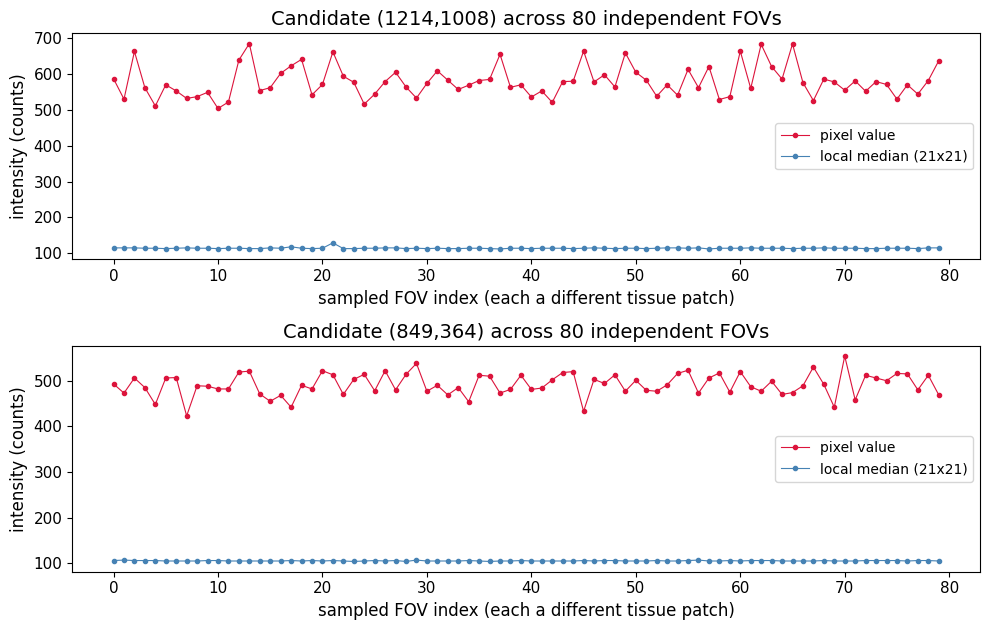

Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/figures/test_hot_pixel_detection_intensity_traces.png


In [9]:
fig, axes = plt.subplots(n_cand, 1, figsize=(10, 3.2 * n_cand), squeeze=False)
for row_i, (_, cand) in enumerate(candidates_df.iterrows()):
    y, x = int(cand.y), int(cand.x)
    g = full_traces[(full_traces.y == y) & (full_traces.x == x)].reset_index(drop=True)
    ax = axes[row_i, 0]
    ax.plot(g.index, g["value"], "o-", ms=3, lw=0.8, color="crimson", label="pixel value")
    ax.plot(g.index, g["local_median"], "o-", ms=3, lw=0.8, color="steelblue", label="local median (21x21)")
    ax.set_title(f"Candidate ({y},{x}) across {len(g)} independent FOVs", fontsize=PLOT_TITLE_FONTSIZE)
    ax.set_xlabel("sampled FOV index (each a different tissue patch)", fontsize=PLOT_LABEL_FONTSIZE)
    ax.set_ylabel("intensity (counts)", fontsize=PLOT_LABEL_FONTSIZE)
    ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
    ax.legend(fontsize=PLOT_LEGEND_FONTSIZE)
fig.tight_layout()
out_path = figures_dir / f"{NOTEBOOK_NAME}_intensity_traces.png"
fig.savefig(out_path, dpi=150)
plt.show()
print(f"Saved: {out_path}")

## 8 — Conclusion

See this notebook's own executed output above for the exact numbers on the
last real run. Read together with `remove_hot_pixels`'s default
`ratio=5.0` threshold (`MERci.acquisition.alignment`): a candidate whose
mean value/local-median ratio sits close to that threshold will only get
flagged in a fraction of frames (borderline, noise-dependent), even though
its raw intensity is essentially constant across every FOV -- i.e. absence
from the flagged-mask in a given frame does not mean the defect wasn't
there, only that it didn't clear the ratio test that frame. The 21x21
local-median trace above (not gated on the flag) is the real ground truth
for whether a candidate is a genuine fixed defect.

This directly bears on the prior session's `median_filter` A/B null result
(`2026_09_02_2300_...md`): if a real, dominant hot pixel is confirmed here
and the true round-to-round drift on this dataset is independently already
near-zero (as that session found), a hot-pixel-pinned-to-zero estimate is
indistinguishable from a correct one on THIS dataset -- consistent with,
not contradicted by, that null result. It does not resolve whether the same
defect would bias a real result on a dataset with genuine non-zero drift.